<a href="https://colab.research.google.com/github/kinchittrivedi/Kaggle/blob/main/Intermediate_NLP_Recurrent_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
google_wiki_words_tensorflow2_250_1_path = kagglehub.model_download('google/wiki-words/TensorFlow2/250/1')

print('Data source import complete.')



  0%|          | 0.00/963M [00:00<?, ?B/s]



100%|██████████| 218/218 [00:00<00:00, 361kB/s]




  0%|          | 0.00/8.27M [00:00<?, ?B/s]




100%|██████████| 23.0k/23.0k [00:00<00:00, 38.1MB/s]

  0%|          | 1.00M/963M [00:00<06:25, 2.62MB/s]
  0%|          | 3.00M/963M [00:00<02:18, 7.26MB/s]

 12%|█▏        | 1.00M/8.27M [00:00<00:02, 2.56MB/s]
  1%|          | 9.00M/963M [00:00<00:47, 21.0MB/s]

 36%|███▋      | 3.00M/8.27M [00:00<00:00, 7.01MB/s]
  2%|▏         | 15.0M/963M [00:00<00:37, 26.6MB/s]

100%|██████████| 8.27M/8.27M [00:00<00:00, 13.4MB/s]

  2%|▏         | 22.0M/963M [00:00<00:27, 35.5MB/s]
  3%|▎         | 26.0M/963M [00:01<00:26, 36.4MB/s]
  4%|▎         | 34.0M/963M [00:01<00:21, 44.6MB/s]
  4%|▍         | 41.0M/963M [00:01<00:19, 48.4MB/s]
  5%|▍         | 48.0M/963M [00:01<00:18, 51.1MB/s]
  6%|▌         | 56.0M/963M [00:01<00:17, 54.7MB/s]
  7%|▋         | 63.0M/963M [00:01<00:18, 51.0MB/s]
  7%|▋         | 70.0M/963M [00:01<00:17, 52.7MB/s]
  8%|▊         | 77.0M/963M [00:01<00:17, 54.0MB/s]
  9%|▉         | 85.0M/963M [00:02<00:16, 56.6MB/s]
 10%|▉         | 92.0M/963M [00:02<00:16, 56.8MB/s]


Data source import complete.


# Intermediate NLP: Recurrent Neural Networks

In our previous lesson **[(Module 2)](https://www.kaggle.com/code/arminnorouzig/intermediate-nlp-preparing-text-data)**, we learned how to map words into dense, meaningful mathematical vectors. However, human language is more than just a bucket of words. *Order matters.*

Consider these two sentences:
1. "The movie was not good, it was excellent."
2. "The movie was not excellent, it was good."

They use the exact same words, but the sequence changes the meaning entirely. Standard feed-forward neural networks look at all inputs at once, missing the flow of time. To solve this, we introduce **Recurrent Neural Networks (RNNs)**.


## The Architecture of Recurrent Networks

An RNN is uniquely designed to process sequential data over time. Instead of passing data only forward from input to output, an RNN has an internal loop. It maintains a **hidden state** (a memory) that carries contextual information from previous time steps into

### The Unrolled RNN Graph

Here is a visual way to show how an RNN processes a sequence of words over time. In this graph $X_t$ is the input at a specific time step (e.g., the word embedding for "movie") and $H_t$ is the "Hidden State". This is the model's memory. Notice how the hidden state from time step $t-1$ flows into the calculation for time step $t$. After reading the whole sentence, the final hidden state contains a summary of the *entire sequence*, which we use to predict the sentiment!

![image.png](attachment:bb8e68fc-9144-4bca-8e05-d9c1fc23aa8b.png)

### The Mathematics of a Simple RNN Layer

Behind the scenes, the RNN calculates its hidden state using basic linear algebra and an activation function (usually `tanh`, which squashes values between -1 and 1 to keep them stable over many steps).

For any given time step $t$, the hidden state $H_t$ is calculated as:
$$ H_t = \tanh(W_{x} X_t + W_{h} H_{t-1} + b) $$

Where:
* $W_x$ are the weights multiplied by the current input word.
* $W_h$ are the weights multiplied by the *previous* hidden state.
* $b$ is the bias term.

This math ensures that the current understanding of the sentence ($H_t$) is a combination of what the model is reading right now ($X_t$) and what it remembers reading previously ($H_{t-1}$).

## Preprocessing Data for Sequences

Before we can build our RNN, we need to prepare our text. As we extensively explored in **Section 1**, neural networks cannot read raw text; they require uniform, numerical matrices.

Instead of building an embedding layer from scratch, we will reuse the exact same preprocessing pipeline we built in **Section 1**. We will use the pre-trained **Wiki-words** model from TensorFlow Hub to instantly convert our text into rich, 250-dimensional mathematical vectors.

Here is a quick recap of the pipeline (completely discussed and visualized in Section 1):
1. **`get_max_length`**: Scans the dataset to find the longest review, setting our target sequence size.
2. **`get_word2vec_enc`**: Iterates through the text and converts each word into a 250D vector using the Wiki-words model.
3. **`get_padded_encoded_texts`**: Prepends zero-vectors (padding) to shorter reviews so every sequence perfectly matches the `max_length`.
4. **`preprocess`**: Orchestrates these functions and returns highly optimized NumPy arrays ready for Keras.

In [14]:
from datasets import load_dataset
ds = load_dataset("stanfordnlp/sst2")
print(ds)

README.md:   0%|          | 0.00/5.27k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 72.8kB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})


In [15]:
import pandas as pd
import numpy as np
import tensorflow_hub as hub
import kagglehub
from datasets import load_dataset

# 1. Load the Data (SST-2 replaces the deleted Kaggle dataset)
ds = load_dataset("stanfordnlp/sst2")

# Build a df with the same 'text' / 'label' schema your pipeline expects.
# SST-2: 'sentence' -> text, 'label' (1=positive, 0=negative) matches yours.
df = pd.DataFrame({
    'text': ds['train']['sentence'],
    'label': ds['train']['label']
})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Optional but recommended: SST-2 train is 67k rows. Embedding all of it token-by-token
# is slow. Subsample to keep it manageable (remove this to use everything).
df = df.head(5000).reset_index(drop=True)

# 2. Download the Wiki-words embedding model
model_path = kagglehub.model_download("google/wiki-words/tensorFlow2/250")
embed = hub.load(model_path)

# 3. Preprocessing helpers (unchanged, with one safety fix)
def get_max_length(df):
    max_length = 0
    for row in df['text']:
        tokens = row.split(" ")
        if len(tokens) > max_length:
            max_length = len(tokens)
    return max_length

def get_word2vec_enc(texts):
    encoded_texts = []
    for text in texts:
        tokens = text.split(" ")
        word2vec_embedding = embed(tokens)
        encoded_texts.append(word2vec_embedding)
    return encoded_texts

def get_padded_encoded_texts(encoded_texts, max_len):
    padded_texts_encoding = []
    for enc_text in encoded_texts:
        enc_text = np.array(enc_text)          # ensure numpy for concatenate
        zero_padding_cnt = max_len - enc_text.shape[0]
        pad = np.zeros((1, 250))
        for i in range(zero_padding_cnt):
            enc_text = np.concatenate((pad, enc_text), axis=0)
        padded_texts_encoding.append(enc_text)
    return padded_texts_encoding

def preprocess(df, max_len):
    texts = df['text'].tolist()
    encoded_texts = get_word2vec_enc(texts)
    padded_encoded_texts = get_padded_encoded_texts(encoded_texts, max_len)
    X = np.array(padded_encoded_texts)
    Y = np.array(df['label'].tolist())
    return X, Y

# 4. Execute
max_length = get_max_length(df)
print(f"The maximum sequence length in the dataset is: {max_length}")

X, Y = preprocess(df, max_length)
print(f"Shape of X (Training Data): {X.shape}")   # (N, max_length, 250)
print(f"Shape of Y (Labels): {Y.shape}")

The maximum sequence length in the dataset is: 51
Shape of X (Training Data): (5000, 51, 250)
Shape of Y (Labels): (5000,)


## Building the RNN with the Keras Functional API

Now, let's architect our sequence model using the highly flexible **Keras Functional API**.

In [16]:
from tensorflow.keras import layers, Model

# 1. Define the Input layer
# Shape is now (max_length, 250) because the words are already embedded!
inputs = layers.Input(shape=(max_length, 250))

# 2. Add the SimpleRNN layer directly
# The hidden state will have 32 dimensions
x = layers.SimpleRNN(units=32)(inputs)

# 3. Add the final Dense classification layer
outputs = layers.Dense(1, activation='sigmoid')(x)

# 4. Construct the Model
model = Model(inputs=inputs, outputs=outputs, name="Simple_RNN_Sentiment")

model.summary()


Model: "Simple_RNN_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 51, 250)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         9,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

**Code Explanation:**
* **Functional API**: Notice how we pass the output of one layer directly as the input to the next layer, like `layer(previous_layer)`. This acts like a data pipeline, giving us explicit control over the mathematical flow from input to output.
* **Input Layer**: `layers.Input(shape=(max_length, 250))`. Because we *already* embedded our words into 250-dimensional vectors during our preprocessing pipeline, our input shape perfectly matches that tensor. We completely skip the traditional Keras `Embedding` layer!
* **SimpleRNN**: `layers.SimpleRNN(units=32)` creates our recurrent loop. As it reads the sequence of embedded words one by one, it continually updates a 32-dimensional "hidden state" memory vector. By default, it returns only the *final* hidden state, which contains the summary of the entire sentence.
* **Dense Layer**: `activation='sigmoid'` on our final layer squashes the RNN's output into a single probability score between 0.0 (Negative sentiment) and 1.0 (Positive sentiment). This activation is highly beneficial for binary classification because its mathematical curve maps any real number into a strict 0 to 1 range, making it perfectly interpretable as a probability. You can read more about it in the [Layer activation functions](https://keras.io/api/layers/activations/)

## Compiling and Training

To train the model, we must define our Loss Function and our Metrics.

In [17]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
print("Starting training...")
history = model.fit(
    X,
    Y,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)


Starting training...
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6267 - loss: 0.6229 - val_accuracy: 0.7230 - val_loss: 0.5661
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7483 - loss: 0.5185 - val_accuracy: 0.7490 - val_loss: 0.5199
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7740 - loss: 0.4842 - val_accuracy: 0.7490 - val_loss: 0.5379
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7812 - loss: 0.4641 - val_accuracy: 0.7520 - val_loss: 0.5145
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7893 - loss: 0.4501 - val_accuracy: 0.7750 - val_loss: 0.4977
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8002 - loss: 0.4269 - val_accuracy: 0.7720 - val_loss: 0.5064
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8142 - loss: 0.4121 - val_accuracy: 0.7720 - val_loss: 0.5045
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8165 - loss: 0.

**Code Explanation:**
* **Optimizer (`adam`)**: The optimizer is the engine that updates the model's weights. `adam` is incredibly popular because it automatically adapts the learning rate during training, making it fast and efficient.
* **Loss (`binary_crossentropy`)**: Because this is a strictly binary problem (Positive vs. Negative), this is the mathematically optimal loss function. It heavily penalizes the model when it is highly confident in a wrong prediction.
* **Metrics (`accuracy`)**: This tells Keras to look at performance based on the percentage of correctly guessed reviews, which is much easier for humans to interpret than the raw loss score.
* **`epochs=50` & `batch_size=32`**: The model will iterate through the entire dataset 50 times (epochs). It won't update its weights after every single sentence; instead, it looks at chunks of 32 reviews at a time (batch size) to make more stable updates.
* **`validation_split=0.2`**: The model holds back 20% of the data during training. At the end of each epoch, it tests itself on this unseen data to calculate `val_loss` and `val_accuracy`. This tells us if the model is actually learning the underlying patterns or just blindly memorizing the training data!

## Checking the Model: Learning Curves and Confusion Matrix

Looking at text output during training is helpful, but graphing the data gives us a much clearer picture of how our model is performing. We will extract the data from our `history` object to plot the **Learning Curves** (Accuracy and Loss over time).

We will also use a **Confusion Matrix** to check our binary classification performance. A confusion matrix breaks down the model's predictions into four categories:
* **True Positives (TP)**: Model predicted Positive, and it actually was Positive.
* **True Negatives (TN)**: Model predicted Negative, and it actually was Negative.
* **False Positives (FP)**: Model predicted Positive, but it was actually Negative (Type I Error).
* **False Negatives (FN)**: Model predicted Negative, but it was actually Positive (Type II Error).

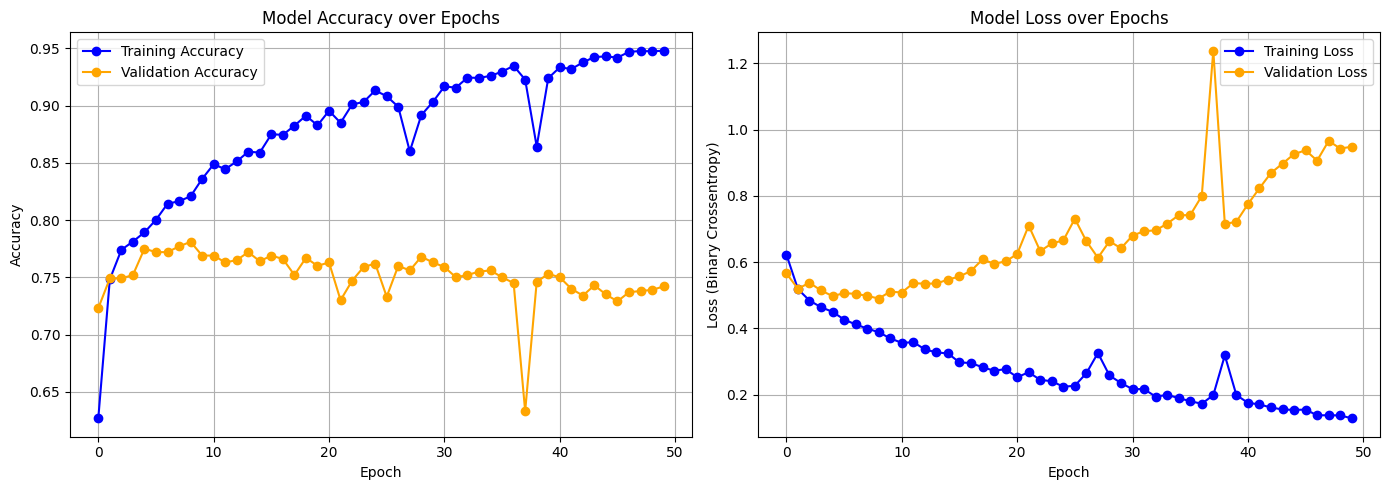

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


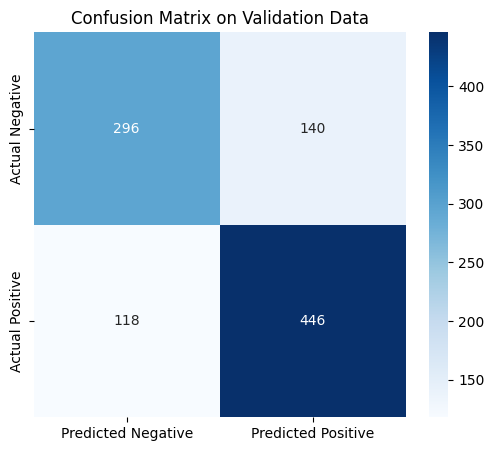

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Plot Accuracy and Loss over Epochs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue', marker='o')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Binary Crossentropy)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# 2. Generate a Confusion Matrix
# We use the final 20% of the data as a proxy for our validation set to match the validation_split
val_split_index = int(len(X) * 0.8)
X_val = X[val_split_index:]
Y_val = Y[val_split_index:]

# Get raw probability predictions from the model
predictions_prob = model.predict(X_val)

# Convert probabilities to binary classes (0 or 1) using a 0.5 threshold
predictions_binary = (predictions_prob > 0.5).astype(int)

# Calculate the confusion matrix
cm = confusion_matrix(Y_val, predictions_binary)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix on Validation Data')
plt.show()



**Analyzing the Results:**
Based on the learning curves and training logs, we can observe a classic machine learning phenomenon: **Overfitting**.

1. **Learning Curves (Overfitting in Action):**
	* **Training vs. Validation Loss:** If you look at the loss plot, the training loss steadily decreases toward a low value, but the validation loss starts to rise significantly after the first few epochs.
	* **Training vs. Validation Accuracy:** Similarly, the training accuracy climbs, but the validation accuracy stagnates at a lower level.
	* **Conclusion:** This divergence means the RNN has perfectly memorized the specific movie reviews in our training set, but it is failing to generalize those rules to new, unseen text. It is essentially finding patterns in the noise!

2. **How to Fix This:**
In future iterations, we can combat this overfitting by introducing techniques such as:
	* **Early Stopping:** Halting training around Epoch 5, before the validation loss starts to climb.
	* **Dropout:** Randomly turning off neurons during training so the model can't rely on specific memorized pathways.
	* **Reducing Model Complexity:** Using fewer units in our `SimpleRNN` layer so it doesn't have the memory capacity to simply memorize the data.

3. **The Confusion Matrix:**
	* The matrix provides a breakdown of our validation accuracy. By looking at the False Positives and False Negatives, you can see exactly which class the model is struggling with the most. A high number of False Positives, for example, would indicate the model is overly optimistic and misclassifies negative reviews as positive.

## Improving the Model: Battling Overfitting by Shrinking Capacity

As we saw in our learning curves, our initial model suffered from **overfitting**. It perfectly memorized the training data (reaching over 91% accuracy) but failed to generalize to the validation data (stuck around 64%).

Why did this happen? Our model might be *too complex* for this specific task. When a neural network has too many parameters (in our previous case, 32 units in the RNN), it has enough "memory capacity" to simply memorize the exact sentences in the training set, rather than learning the actual rules of positive and negative sentiment.

The simplest and most fundamental way to fight overfitting is to **shrink the size of the model**. By restricting the number of units in our `SimpleRNN` layer, we force the network to focus only on the most prominent, generalizable patterns in the text.

Let's build a smaller version of our RNN by dropping the units from 32 down to 8!

Model: "Smaller_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 51, 250)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 8)              │         2,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,081 (8.13 KB)

 Trainable params: 2,081 (8.13 KB)

 Non-trainable params: 0 (0.00 B)

Starting training for the Smaller Model...


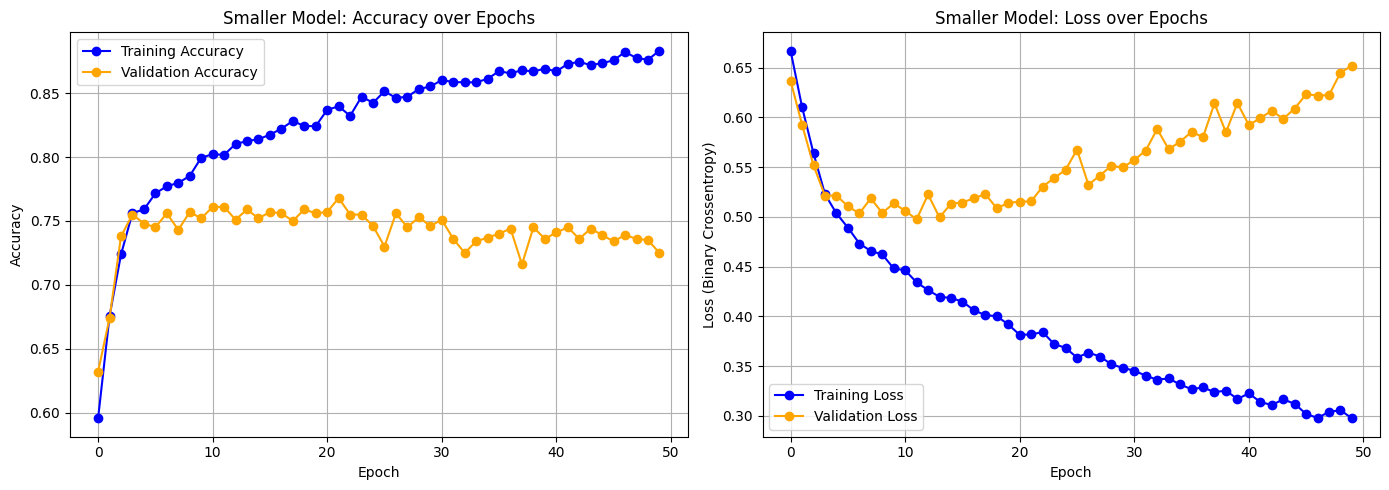

In [19]:
from tensorflow.keras import layers, Model

# 1. Define Input
inputs = layers.Input(shape=(max_length, 250))

# 2. Add a SMALLER SimpleRNN layer
# We reduce the capacity from 32 units down to just 8 units!
x = layers.SimpleRNN(units=8)(inputs)

# 3. Add the final Dense classification layer
outputs = layers.Dense(1, activation='sigmoid')(x)

# 4. Construct and Compile the Smaller Model
smaller_model = Model(inputs=inputs, outputs=outputs, name="Smaller_RNN")

smaller_model.summary()

smaller_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5. Train the Smaller Model
print("Starting training for the Smaller Model...")
smaller_history = smaller_model.fit(
    X,
    Y,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Plot Accuracy and Loss over Epochs for the Smaller Model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(smaller_history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
ax1.plot(smaller_history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
ax1.set_title('Smaller Model: Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(smaller_history.history['loss'], label='Training Loss', color='blue', marker='o')
ax2.plot(smaller_history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
ax2.set_title('Smaller Model: Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Binary Crossentropy)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Look at the difference in the learning curves! In our first model (with 32 units), the model quickly memorized the training data, leading to a massive gap between the training and validation curves.

By simply shrinking the model's memory capacity (from 32 units down to 8 units), we constrained its ability to memorize. As you can see in the logs, the training accuracy and validation accuracy stay much closer together. The validation loss is also much more stable.

While shrinking model size is a powerful first step, modern NLP practitioners also use advanced regularization techniques like Dropout and Early Stopping to safely squeeze out even more performance without overfitting. In the next section we will explore more advanced sequence architectures like **LSTMs (Long Short-Term Memory)**!


## Conclusion & Next Steps
In this module, we built a Simple RNN to read text sequentially, carrying forward a "hidden state" memory of what was said previously. We also saw firsthand how easily these powerful neural networks can overfit—memorizing the exact training data instead of learning the underlying sentiment. We battled this by shrinking the model's capacity to force better generalization.

We can continue to fight overfitting using techniques like Early Stopping (halting training before validation loss rises) or Dropout layers (randomly ignoring neurons during training). However, Simple RNNs still suffer from a fundamental mathematical flaw: the "Vanishing Gradient Problem." When dealing with very long paragraphs, they essentially forget the context from the beginning of the text.

To solve this memory loss, we need a smarter recurrent architecture. In **[Module 4: Long Short-Term Memory (LSTM)](https://www.kaggle.com/code/arminnorouzig/intermediate-nlp-long-short-term-memory-lstm)**, we will introduce Long Short-Term Memory (LSTM) networks. You will learn how LSTMs use complex mathematical gates to maintain a continuous "conveyor belt" of memory across long sequences!